Customer Churn Prediction Project##

In [1]:
## load data set

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Check Dataset Information##

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 14)


## data cleaning##

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## check duplicate##

In [13]:
df.duplicated().sum()

np.int64(0)

# Remove Unnecessary Columns

In [14]:
df.drop(['RowNumber','CustomerId','Surname'],
        axis=1,
        inplace=True)

# Data Analysis (EDA)

In [15]:
##Churn Distribution

In [16]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [17]:
#Churn Percentage

In [18]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [ ]:
##average by balance geography

In [20]:
df.groupby('Geography')['Balance'].mean()

Geography
France      62092.636516
Germany    119730.116134
Spain       61818.147763
Name: Balance, dtype: float64

In [21]:
##average age by gender

In [24]:
df.groupby('Gender')['Age'].sum()

Gender
Female    178260
Male      210958
Name: Age, dtype: int64

In [23]:
##churn count by gender

In [25]:
df.groupby ('Gender')['Exited'].sum()

Gender
Female    1139
Male       898
Name: Exited, dtype: int64

# Visualizations

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [27]:
##Pie Chart (Churn Distribution)

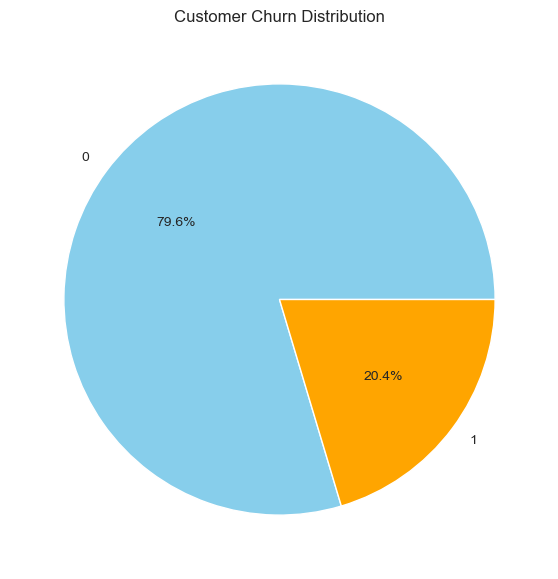

In [28]:
plt.figure(figsize=(7,7))

df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange']
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [29]:
##Age Distribution

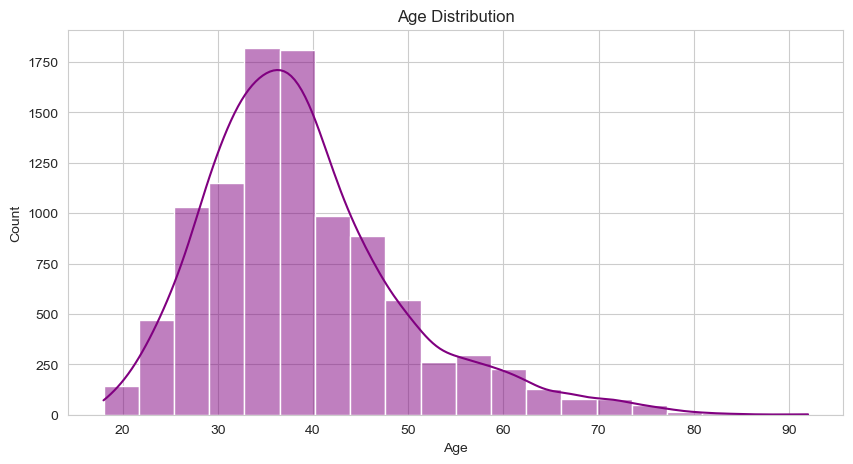

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("Age Distribution")
plt.show()

In [32]:
##Gender vs Churn

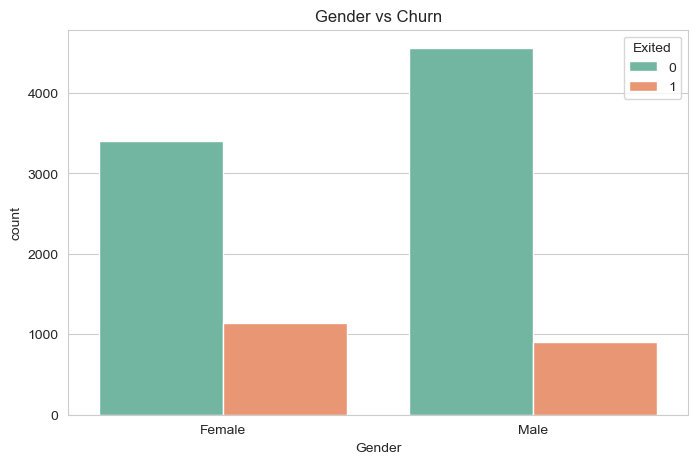

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df,
    palette='Set2'
)

plt.title("Gender vs Churn")
plt.show()

In [35]:
##Correlation Heatmap##

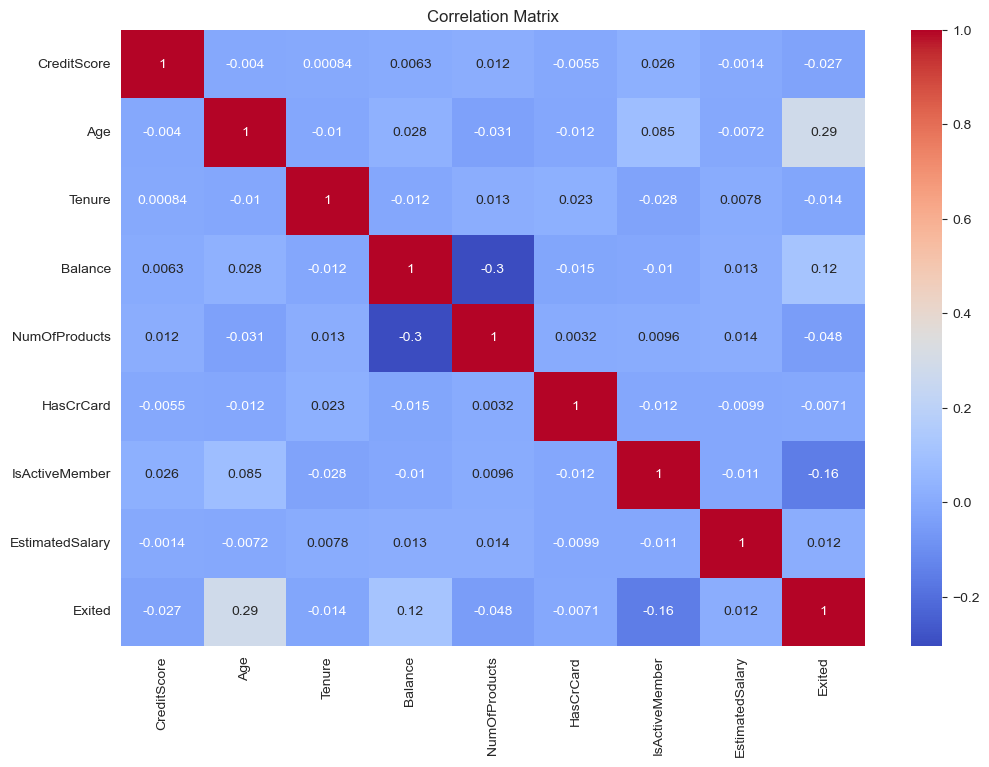

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

In [37]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender'],
    drop_first=True
)

In [39]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


# Train-Test Split
Define X and y

In [40]:
X = df.drop('Exited', axis=1)

y = df['Exited']

In [41]:
##Split Data

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Machine Learning Model

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

C:\Users\lakshya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
##Prediction#

In [46]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 0 0 0 0 0 0]


# Model Evaluation

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.8


# Confusion Matrix

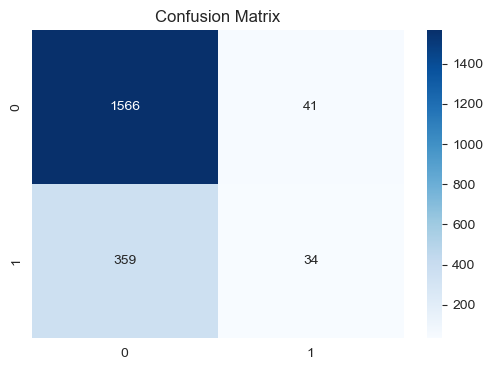

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

In [49]:
##Classification Report

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.89      1607
           1       0.45      0.09      0.15       393

    accuracy                           0.80      2000
   macro avg       0.63      0.53      0.52      2000
weighted avg       0.74      0.80      0.74      2000

